In [1]:
#导入相关库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
n = 400 #训练样本
n1 = 200#预测样本
from pandas import read_csv
import math
import random
import csv

import numpy as np
import pandas as pd
from numpy import matrix

from sklearn.svm import SVC
import statsmodels.api as sm
import pylab as pl
import scipy.linalg as sl

def I_12(x):
    if x >= 0:
        return 1
    else:
        return 0

def I_11(x):
    if x < 0:
        return 1
    else:
        return 0

def I_22(x):
    if x >= 0:
        return 1
    else:
        return 0


def I_21(x):
    if x < 0:
        return 1
    else:
        return 0

def I_12or(x):
    if x >= 0:
        return 1
    else:
        return 0

def I_11or(x):
    if x < 0:
        return 1
    else:
        return 0

def I_22or(x):
    if x >= -1:
        return 1
    else:
        return 0


def I_21or(x):
    if x< -1:
        return 1
    else:
        return 0
    
# Soft Thresholding
def ST(b, lam):
    st = np.sign(b) * max(abs(b) - lam, 0)
    return st
def MCP(a,b,gamma,rho,lam):
    if abs(a)<= gamma*rho*b:
        return ST(a,b)/(1-1/(gamma*lam/b))
    else:
        return a
from scipy.special import comb
def rand_index_score(clusters, classes):
    tp_plus_fp = comb(np.bincount(clusters), 2).sum()
    tp_plus_fn = comb(np.bincount(classes), 2).sum()
    A = np.c_[(clusters, classes)]
    tp = sum(comb(np.bincount(A[A[:, 0] == i, 1]), 2).sum()
            for i in set(clusters))
    fp = tp_plus_fp - tp
    fn = tp_plus_fn - tp
    tn = comb(len(A), 2) - tp - fp - fn
    return (tp + tn) / (tp + fp + fn + tn)
#重复循环50次试一下
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [28]:
X1 = np.random.uniform(low=0.0, high=1, size = n)
Z1 = np.random.uniform(low=0.0, high=1, size = n)
np.sum(X1 * Z1 > 0.2)

np.int64(190)

In [2]:
np.random.seed(110)
Deviation_0 = []
Deviation_1 = []
Deviation_2 = []
Deviation1_1 = []
Deviation1_2 = []
Deviation2_1 = []
Deviation2_2 = []
beta0_all = []
beta1_all = []
beta2_all = []
alpha1_1all =[]
alpha1_2all =[]
alpha2_1all = []
alpha2_2all = []
ACC1 = []
ACC2 = []
ACC_final = []
ACC_pre = []
K1 = []
K2 =  []
RI1 = []
RI2 = []
ACCp2 = []
ACCp1 = []
ACCp_final = []
beta0_allor = []
beta1_allor = []
beta2_allor = []
alpha1_1allor = []
alpha1_2allor = []
alpha2_1allor = []
alpha2_2allor = []
lst1 = []
lst2 = []
Pre1 = []
Pre2 = []
import time
start = time.perf_counter()
for i in range(200):
    print(i)
    #生成要训练的数据
    beta_0 = 1
    beta_1 = 1
    beta_2 = 1
    X1 = np.random.uniform(low=0.0, high=1, size = n)
    Z1 = np.random.uniform(low=0.0, high=1, size = n)
    random_u = X1 * Z1


    #定义变系数beta1(x)
    def alpha11(x):
        if (x >= 0) & (x < 0.2):
            return -1
        elif (x >= 0.2) & (x <=  1):
            return 1
        else:
            return None

    #生成变系数beta1(x)数据
    alpha1 = []
    for i in random_u:
        alpha1_1 = alpha11(i)
        alpha1.append(alpha1_1)

    #定义系数alpha2
    def alpha22(x):
        if (x >= 0) & (x < 0.2):
            return -1.5
        elif (x >= 0.2) & (x <= 1):
            return 0.5
        else:
            return None

    alpha2 = []
    for i in random_u:
        alpha2_2 = alpha22(i)
        alpha2.append(alpha2_2)

    # 随机生成X1 X2
    X0 = np.ones(n)
    #X1 = np.random.normal(loc=0,scale=1,size=n)
    X2 = np.random.normal(loc=0,scale=1,size=n)
    # 随机生成Z1 Z2

    #Z1 = np.random.binomial(n = 1,p = 0.5,size = n)
    Z2 = np.random.normal(loc=0,scale=1,size=n)
    # 随机生成服从正态分布的噪声
    epli =np.random.normal(loc=0,scale=0.5,size=400)#从正态（高斯）分布中抽取随机样本。
    #获取Y
    def func(X0,X1,X2,Z1,Z2):
        Y = A * X0 + B* X1 + C * X2 + D * Z1 + E* Z2 + eplison
        return Y
    Y1 = []
    for i in range(n):#生成数据的长度
        A = beta_0
        B = beta_1
        C  = beta_2
        D = alpha1[i]
        E = alpha2[i]
        eplison = epli[i]
        X0_0 = X0[i]
        X1_1 = X1[i]
        X2_1 = X2[i]

        Z1_1 = Z1[i]
        Z2_1 = Z2[i]
        Y1_1 = func(X0_0,X1_1,X2_1,Z1_1,Z2_1)
        Y1.append(Y1_1)

    #生成一列索引
    index = []
    for i in range(n):
        index_1 = i
        index.append(int(index_1))

    data_arry = []
    data_arry.append(index)
    data_arry.append(Y1)
    data_arry.append(X0)
    data_arry.append(X1)
    data_arry.append(X2)
    data_arry.append(Z1)
    data_arry.append(Z2)
    data_arry.append(random_u)
    data_arry.append(alpha1)
    data_arry.append(alpha2)
    np_data = np.array(data_arry)
    np_data = np_data.T
    np_data = np.array(np_data)
    save = pd.DataFrame(np_data,columns = ['index','Y1','X0','X1','X2', 'Z1', 'Z2','U','alpha1','alpha2']) 
    save.to_csv('ZGDP 1.1 first.csv',index=False,header=True)
    #随机生成要预测的数据
    X1 = np.random.uniform(low=0.0, high=1, size = n1)
    Z1 = np.random.uniform(low=0.0, high=1.00, size = n1)
    randompre_u = X1 * Z1
    #randompre_u = np.random.uniform(low=0.0, high=1.0, size = n1)
    #生成变系数beta1(x)数据
    alpha1p = []
    for i in randompre_u:
        alpha1_1 = alpha11(i)
        alpha1p.append(alpha1_1)
    alpha2p = []
    for i in randompre_u:
        alpha2_2 = alpha22(i)
        alpha2p.append(alpha2_2)

    # 随机生成X1 X2
    X0 = np.ones(n1)
    #X1 = randompre_u
    #X1 = np.random.normal(loc=0,scale=1,size=n)
    X2 = np.random.normal(loc=0,scale=1,size=n1)
    # 随机生成Z1 Z2

    #Z1 = np.random.binomial(n = 1,p = 0.5,size = n1)
    Z2 = np.random.normal(loc=0,scale=1,size=n1)
    # 随机生成服从正态分布的噪声
    eplip =np.random.normal(loc=0,scale=0.5,size=n1)#从正态（高斯）分布中抽取随机样本。

    Yp = []
    for i in range(n1):#生成数据的长度
        A = beta_0
        B = beta_1
        C  = beta_2
        D = alpha1p[i]
        E = alpha2p[i]
        eplison = eplip[i]
        X0_0 = X0[i]
        X1_1 = X1[i]
        X2_1 = X2[i]

        Z1_1 = Z1[i]
        Z2_1 = Z2[i]
        Y1_1 = func(X0_0,X1_1,X2_1,Z1_1,Z2_1)
        Yp.append(Y1_1)
    #生成一列索引
    indexp = []
    for i in range(n1):
        index_1 = i
        indexp.append(int(index_1))
    data_arrypre = []
    data_arrypre.append(indexp)
    data_arrypre.append(Yp)
    data_arrypre.append(X0)
    data_arrypre.append(X1)
    data_arrypre.append(X2)
    data_arrypre.append(Z1)
    data_arrypre.append(Z2)
    data_arrypre.append(randompre_u)
    data_arrypre.append(alpha1p)
    data_arrypre.append(alpha2p)
    np_datapre = np.array(data_arrypre)
    np_datapre = np_datapre.T
    np_datapre = np.array(np_datapre)
    savepre = pd.DataFrame(np_datapre,columns = ['index','Y1','X0','X1','X2', 'Z1', 'Z2','U','alpha1','alpha2']) 
    savepre.to_csv('ZGDP 1.1 first pre.csv',index=False,header=True) 
    filenamepre = 'ZGDP 1.1 first pre.csv'
    datapre = read_csv(filenamepre)
    #生成判罚阵
    
    # 导入随机生成的数据
    filename = 'ZGDP 1.1 first.csv'
    data = read_csv(filename)

    with open('ZGDP 1.1 first.csv','r')as file:#'r'为读取文本
        reader = csv.DictReader(file)
        datas = [row for row in reader]

    def distance(d1, d2):
        """2范数，即欧几里得距离
           1范数，曼哈顿距离"""
        res = 0
        for key in("U"):
            #res+=abs((float(d1[key])-float(d2[key])))#一范数
            res+=(float(d1[key])-float(d2[key]))**2  #二范数
        return res
    #定义距离函数
    #影响knn的一般为距离的定义和k的取值，所以我把距离函数单独定义一下，这样方便更换

    #KNN计算离点最近的K-1个点，这是因为此时我在计算距离时并没有把自身排除，在排序时总有它自身距离自身为0的一个点
    K = 5  #以2-NN为例
    def KNN(data):
        #1.距离
        res = [
            {"index": train['index'],"distance": distance(data,train)}
            #diatance(data,train)
            for train in datas
        ]
        #2升序排列
        res = sorted(res , key = lambda item:item["distance"])
         #3.取前K个
        res2 = res[0:K]
        r2 = []
        for r in res2:
            r_1 = r["index"]
            r2.append(r_1)
        #print(res2)
        #print(r2)
        return r2
    k = 4#与前面的K-1相等
    G = np.zeros(shape=(n*k,n))#nk*n维矩阵
    #G  生成nk*n的零矩阵

    for i in range(0,n):
        for m in range(0,k):
            G[m+k*i][i] =  1
            ##k行一个元素为1 
    #G

    for j in range(0,n):
        list1 = KNN(datas[j])
        list2 = list1[1:]#取最近的K-1 = k个值
        for i in range(0,k):
            r_12 = int(float(list2[i]))
            G[i+j*k][r_12] = -1
            #G[i+j][#knn的那几个元素] = -1 
    #生成所需要的G矩阵
    
    #给初值
    lam = 0.00001
    m = 2
    I_p = np.diag(np.ones(m))
    A = np.kron(G,I_p)
    X = (np.array([data['X0'].values,data['X1'].values,data['X2'].values])).T
    Z = np.array([data['Z1'].values,data['Z2'].values]).T
    Z_1 = np.diag(data['Z1'].values)
    Z_2 = np.diag(data['Z2'].values)
    Y_1 = data['Y1'].values
    I_n = np.diag(np.ones(n))
    Q_1 = np.dot(X,np.linalg.pinv(np.dot(X.T,X)))
    Q_X = I_n - np.dot(Q_1,X.T)

    Z00 = []
    for i in range(n):
        Z00 = sl.block_diag(Z00,Z[i])
        i = i+1
    Z00 = np.delete(Z00, 0, 0) #块对角化.Z = (Z_1^T,...,Z_n^T)
    
    alpha_intial = np.dot(np.linalg.pinv(np.dot(np.dot(Z00.T,Q_X),Z00)+lam* np.dot(A.T,A)),np.dot(np.dot(Z00.T,Q_X),Y_1))
    beta_intial = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),Y_1 - np.dot(Z00,alpha_intial))
    alpha11 = []
    alpha22 = []
    for i in range(n):
        alpha_11 = alpha_intial[2*i]
        alpha_22 = alpha_intial[2*i+1]
        alpha11.append(alpha_11)
        alpha22.append(alpha_22)
    alpha11 = np.array(alpha11)
    alpha22 = np.array(alpha22)
    
    alpha1_before  = data['alpha1'].values
    alpha2_before  = data['alpha2'].values
    beta = beta_intial
    lam =1
    rho = 1
    gamma  = 2
    alpha1 = alpha11
    alpha2 = alpha22

    alpha1_old = alpha1
    alpha2_old = alpha2
    delta1 = np.dot(G,alpha1)
    delta2 = np.dot(G,alpha2)
    mu1 = np.ones(4*n) - 1
    mu2 = np.ones(4*n) - 1
    epsilon = 1e-4
    k=0
    F1=[]
    F2 = []
    F3 = []
    #每步计算结果
    while k < 50:#迭代
        alpha1 = np.dot(np.linalg.pinv(np.dot(np.dot(Z_1.T,Q_X),Z_1) +rho* np.dot(G.T,G)),
                        (np.dot(np.dot(Z_1.T,Q_X),(Y_1 - np.dot(Z_2,alpha2))) + rho * np.dot(G.T,delta1 - 1/rho*mu1)))
        alpha2 = np.dot(np.linalg.pinv(np.dot(np.dot(Z_2.T,Q_X),Z_2) + rho* np.dot(G.T,G)),
                        (np.dot(np.dot(Z_2.T,Q_X),(Y_1 - np.dot(Z_1,alpha1))) + rho * np.dot(G.T,delta2 - 1/rho*mu2)))
        beta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),Y_1 - np.dot(Z_1,alpha1)-np.dot(Z_2,alpha2)) 

        ras1 = []
        bb1 = np.dot(G,alpha1)+1/rho*mu1
        for i in range(4*n):
            b  = bb1[i]
            res1 = MCP(b,lam/rho,gamma,rho,lam)
            ras1.append(res1)
        delta1 = np.asarray(ras1)
        ras2 = []
        bb2 = np.dot(G,alpha2)+1/rho*mu2
        for i in range(4*n):
            b  = bb2[i]
            res2 = MCP(b,lam/rho,gamma,rho,lam)
            ras2.append(res2)
        delta2 = np.asarray(ras2)
        mu1 = mu1 + rho*(np.dot(G,alpha1) - delta1)
        mu2 = mu2 + rho*(np.dot(G,alpha2) - delta2)
        k = k+1

        #停止迭代的条件 
        F1.append(beta)
        if np.linalg.norm(mu1)/(4*n) < epsilon and np.linalg.norm(mu2)/(4*n) < epsilon:
                break
        else:
            alpha1_old = alpha1 
            alpha2_old = alpha2
            #迭代过程 
    #预测组数K1，K2
    alpha1_sort = np.sort(alpha1)
    lst1.append(alpha1)
    lst2.append(alpha2)
    biandian1 = np.diff(alpha1_sort)
    location_1 = np.array(np.where(abs(biandian1) > 0.4))
    location_1 = np.insert(location_1, 0, 0)  # 在0号位置插入元素0
    location_1 = np.insert(location_1, len(location_1), 398)  # 在数组末尾插入元素
    #location_11 = np.where(np.diff(location_1)> 0.05*800)
    K_1 = np.count_nonzero(np.diff(location_1)> 0.1*n)
    K1.append(K_1)
    alpha2_sort = np.sort(alpha2)
    biandian2 = np.diff(alpha2_sort)
    location_2 = np.array(np.where(abs(biandian2) > 0.4))
    location_2 = np.insert(location_2, 0, 0)  # 在0号位置插入元素0
    location_2 = np.insert(location_2, len(location_2), 398)  # 在数组末尾插入元素
    K_2 = np.count_nonzero(np.diff(location_2)> 0.05*n)
    K2.append(K_2)
    #尝试计算RI
    filename = 'ZGDP 1.1 first.csv'
    data = read_csv(filename)    
    result_array = []
    index_1 = data['index'].values
    Y1 = data['Y1'].values
    Z1 = data['Z1'].values
    Z2 = data['Z2'].values
    X0 = data['X0'].values
    X1 = data['X1'].values
    X2 = data['X2'].values
    result_array.append(index_1)
    result_array.append(Y1)
    result_array.append(Z1)
    result_array.append(Z2)
    result_array.append(X0)
    result_array.append(X1)
    result_array.append(X2)
    result_array.append(random_u)
    result_array.append(alpha1_before)
    result_array.append(alpha2_before)
    alpha1_unsort = np.squeeze(np.array(alpha1))
    result_array.append(alpha1_unsort)
    alpha2_unsort = np.squeeze(np.array(alpha2))
    result_array.append(alpha2_unsort)
    result_data = np.array(result_array)
    result_data = result_data.T
    result = pd.DataFrame(result_data, columns = ['index','Y','Z1','Z2','X0','X1','X2','U','alpha1_origin','alpha2_origin','alpha1','alpha2'])   
    result.sort_values(by="alpha1" , inplace=True, ascending=True)
    result['new_label1diff']=abs(result['alpha1'].diff(-1).shift())#做alpha1差分,添加列
    result = result.fillna(0)#nan替换为0
    result.reset_index(drop=True, inplace=True)#行号变回来，为了便于根据差分赋值

    dfsuoyin11 = result.loc[result['new_label1diff'] > 0.5] #提取变点的位置
    biandianxu11 = dfsuoyin11.index.values
    biandianxu11 = np.insert(biandianxu11, 0, 0, axis=None)
    biandianxu11 = np.insert(biandianxu11, len(biandianxu11), 400, axis=None)
    labels_pred11 = np.zeros(400,int)
    for i in range(len(biandianxu11)-1):
        labels_pred11[biandianxu11[i]:biandianxu11[i+1]] = i
    labels_pred11[biandianxu11[len(biandianxu11)-1]:400] = len(biandianxu11)#给出预测的分组结果
    result['labels1_true'] = result.alpha1_origin.apply(lambda x: 1 if x == -1  else 0)
    labels1_true = result['labels1_true'].values
    RI1_1 = rand_index_score(labels1_true, labels_pred11)
    RI1.append(RI1_1)
 
    result.sort_values(by="alpha2" , inplace=True, ascending=True)
    result['new_label2diff']=abs(result['alpha2'].diff(-1).shift())#做alpha2差分,添加列
    result = result.fillna(0)#nan替换为0
    result.reset_index(drop=True, inplace=True)#行号变回来，为了便于根据差分赋值
    dfsuoyin21 = result.loc[result['new_label2diff'] > 0.5] 
    biandianxu21 = dfsuoyin21.index.values
    biandianxu21 = np.insert(biandianxu21, 0, 0, axis=None)
    biandianxu21 = np.insert(biandianxu21, len(biandianxu21), 400, axis=None)
    labels_pred21 = np.zeros(400,int)
    for i in range(len(biandianxu21)-1):
        labels_pred21[biandianxu21[i]:biandianxu21[i+1]] = i
    labels_pred21[biandianxu21[len(biandianxu21)-1]:400] = len(biandianxu21)#根据变点和其索引赋值分组标签
    result['labels2_true'] = result.alpha2_origin.apply(lambda x: 1 if x == 0.5  else 0)
    labels2_true = result['labels2_true'].values
    RI2_1 = rand_index_score(labels2_true, labels_pred21)
    RI2.append(RI2_1)
    
    #做分类
    U1 = np.ones(n)
    result.insert(4, 'U1',U1, allow_duplicates=False)
    label1= []
    for i in range(n):
        if result.alpha1[i]>=0:
            label1_1 = 1
        else:
            label1_1 = -1
        label1.append(label1_1)
    label1 = np.array(label1)
    clf1 = SVC(kernel='linear',C=10)  
    Z_ob = result[['U','U1']]
    clf1.fit(X=Z_ob,y=label1)
    accsvc1 = clf1.score(X=Z_ob,y=label1)#得分
    accp1 = clf1.predict(X=Z_ob) 
    acc1 = 1-np.count_nonzero((accp1 - label1))/len(accp1)
    ACC1.append(acc1)
    #做预测
    U11 = np.ones(n1)
    datapre.insert(4, 'U1',U11, allow_duplicates=False)
    pre1 = clf1.predict(datapre[['U','U1']])
    acc_pre1 = 1-np.count_nonzero((pre1 - datapre.alpha1))/len(pre1)
    ACCp1.append(acc_pre1)
    x_min,x_max = 0,1#取横坐标的取值范围
    y_min,y_max = 0,1#取纵坐标的取值范围
    xx,yy = np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))#生成网格点
    Z = clf1.predict(np.c_[xx.ravel(),yy.ravel()])#用我们的模型预测出来的网格点中的所有的值
    Pre1.append(Z)

    #2的准确率
    label2= []
    for i in range(n):
        if result.alpha2[i]>-0.5:
            label2_1 = 1
        else:
            label2_1 = -1
        label2.append(label2_1)
    label2 = np.array(label2)
    clf2 = SVC(kernel='linear',C=10)
    clf2.fit(X=Z_ob,y=label2)
    accsvc2 = clf2.score(X=Z_ob,y=label2)#得分
    accp2 = clf2.predict(X=Z_ob)
    Z2 = clf2.predict(np.c_[xx.ravel(),yy.ravel()])
    Pre2.append(Z2)
    
    label2_result = []
    for i in range(n):
        if result.alpha2_origin[i] == -1.5:
            label2_result1 = -1
        else:
            label2_result1 = 1
        label2_result.append(label2_result1)
    label2_result = np.array(label2_result)
    acc2 = 1-np.count_nonzero((accp2 - label2_result))/len(accp2)
    ACC2.append(acc2) 
    #做预测
    pre2_datapre = []
    for i in range(n1):
        if datapre.alpha2[i] == -1.5:
            pre2_datapre1 = -1
        else:
            pre2_datapre1 = 1
        pre2_datapre.append(pre2_datapre1)
    pre2_datapre = np.array(pre2_datapre)
    pre2 = clf2.predict(datapre[['U','U1']])
    acc_pre2 = 1-np.count_nonzero((pre2 - pre2_datapre))/len(pre2)
    ACCp2.append(acc_pre2)
    #计算准确率
    acc_origin = []
    acc_origin.append(accp1 - label1)
    acc_origin.append(accp2 - label2_result)
    acc_origin = np.array(acc_origin)
    #训练集的总正确率
    acc1_final = np.array(np.linalg.norm(x=acc_origin.T, ord=1, axis=1, keepdims=False))
    acc_final = np.sum(acc1_final==0)/len(acc1_final)
    ACC_final.append(acc_final)
    #测试集的准确率
    acc_pre = []
    acc_pre.append(pre1 - datapre.alpha1)
    acc_pre.append(pre2 - pre2_datapre)
    acc_pre = np.array(acc_pre)
    acc2_final = np.array(np.linalg.norm(x=acc_pre.T, ord=1, axis=1, keepdims=False))
    acc_prefinal = np.sum(acc2_final==0)/len(acc2_final)
    ACC_pre.append(acc_prefinal)
 
    
    z1 = np.array(result.Z1)
    z2 = np.array(result.Z2)
    #oracle下回归结果
    
    I11_or = []
    for i in result.alpha1_origin:
        I1_1or = I_11or(i)
        I11_or.append(I1_1or)
    I12_or = []
    for i in result.alpha1_origin:
        I1_2or = I_12or(i)
        I12_or.append(I1_2or)
        
    I21_or = []
    for i in result.alpha2_origin:
        I2_1or = I_21or(i)
        I21_or.append(I2_1or)
    I22_or = []
    for i in result.alpha2_origin:
        I2_2or = I_22or(i)
        I22_or.append(I2_2or)
        
    zI_111or = z1*I11_or
    zI_112or = z1*I12_or
    zI_221or = z2*I21_or
    zI_222or = z2*I22_or
    data_modelor = []
    Y1 = result['Y'].values
    X0 = result['X0'].values
    X1 = result['X1'].values
    X2 = result['X2'].values
    data_modelor.append(Y1)
    data_modelor.append(X0)
    data_modelor.append(X1)
    data_modelor.append(X2)
    data_modelor.append(zI_111or)
    data_modelor.append(zI_112or)
    data_modelor.append(zI_221or)
    data_modelor.append(zI_222or)
    data_modelor = np.array(data_modelor)
    data_modelor = data_modelor.T
    data_modelor = pd.DataFrame(data_modelor, columns = ['Y','X0','X1','X2','z1*I11','z1*I12','z2*I21','z2*I22']) 
    train_colsor = data_modelor.columns[1:]
    linear_or = sm.OLS(data_modelor['Y'],data_modelor[train_colsor])
    result_for = linear_or.fit()
    beta0_or = result_for.params.iloc[0]
    beta1_or = result_for.params.iloc[1]
    beta2_or = result_for.params.iloc[2]
    alpha1_1or = result_for.params.iloc[3]
    alpha1_2or = result_for.params.iloc[4]
    alpha2_1or = result_for.params.iloc[6]
    alpha2_2or = result_for.params.iloc[5]

    beta0_alor = beta0_or
    beta1_alor = beta1_or
    beta2_alor = beta2_or
    alpha1_1alor = alpha1_1or
    alpha1_2alor = alpha1_2or
    alpha2_1alor = alpha2_1or
    alpha2_2alor = alpha2_2or
    
    beta0_allor.append(beta0_alor)
    beta1_allor.append(beta1_alor)
    beta2_allor.append(beta2_alor)
    alpha1_1allor.append(alpha1_1alor)
    alpha1_2allor.append(alpha1_2alor)
    alpha2_1allor.append(alpha2_1alor)
    alpha2_2allor.append(alpha2_2alor) 

    #knn fused penalty function 下的分组结果做判罚
    I11 = []
        #for i in random_u:
    for i in label1:
    #for i in alpha1_result:
        I1_1 = I_11(i)
        I11.append(I1_1)
    I12 = []
    #for i in alpha1_result:
    for i in label1:
        #for i in random_u:
        I1_2 = I_12(i)
        I12.append(I1_2)

    I21 = []
    for i in label2:
        #for i in random_u:
    #for i in alpha2_result:
        I2_1 = I_21(i)
        I21.append(I2_1)
    I22 = []
        #for i in random_u:
        #for i in alpha2_result:
    for i in label2:
    #for i in alpha2_result:
        I2_2 = I_22(i)
        I22.append(I2_2)
    zI_111 = z1*I11
    zI_112 = z1*I12
    zI_221 = z2*I21
    zI_222 = z2*I22
    data_model = []
    Y1 = result['Y'].values
    X0 = result['X0'].values
    X1 = result['X1'].values
    X2 = result['X2'].values
    data_model.append(Y1)
    data_model.append(X0)
    data_model.append(X1)
    data_model.append(X2)
    data_model.append(zI_111)
    data_model.append(zI_112)
    data_model.append(zI_221)
    data_model.append(zI_222)
    data_model = np.array(data_model)
    data_model = data_model.T
    data_model = pd.DataFrame(data_model, columns = ['Y','X0','X1','X2','z1*I11','z1*I12','z2*I21','z2*I22']) 
    train_cols = data_model.columns[1:]
    linear = sm.OLS(data_model['Y'],data_model[train_cols])
    result_f = linear.fit()
    result_f.summary()
    beta0_old = 1
    beta1_old = 1
    beta2_old = 1
    alpha1_1_old = -1
    alpha1_2_old = 1
    alpha2_1_old = -1.5
    alpha2_2_old = 0.5


    beta0 = result_f.params.iloc[0]
    beta1 = result_f.params.iloc[1]
    beta2 = result_f.params.iloc[2]
    alpha1_1 = result_f.params.iloc[3]
    alpha1_2 = result_f.params.iloc[4]
    alpha2_1 = result_f.params.iloc[5]
    alpha2_2 = result_f.params.iloc[6]

    deviation_0 = beta0-beta0_old
    deviation_1 = beta1-beta1_old
    deviation_2 = beta2-beta2_old

    deviation1_1 = (alpha1_1-alpha1_1_old)
    deviation1_2 = (alpha1_2-alpha1_2_old)
    deviation2_1 = (alpha2_1-alpha2_1_old)
    deviation2_2 = (alpha2_2-alpha2_2_old)
    
    beta0_al = beta0
    beta1_al = beta1
    beta2_al = beta2
    alpha1_1al = alpha1_1
    alpha1_2al = alpha1_2
    alpha2_1al = alpha2_1
    alpha2_2al = alpha2_2
    Deviation_0.append(deviation_0)
    Deviation_1.append(deviation_1)
    Deviation_2.append(deviation_2)
    Deviation1_1.append(deviation1_1)
    Deviation1_2.append(deviation1_2)
    Deviation2_1.append(deviation2_1)
    Deviation2_2.append(deviation2_2)
    beta0_all.append(beta0_al)
    beta1_all.append(beta1_al)
    beta2_all.append(beta2_al)
    alpha1_1all.append(alpha1_1al)
    alpha1_2all.append(alpha1_2al)
    alpha2_1all.append(alpha2_1al)
    alpha2_2all.append(alpha2_2al) 

end = time.perf_counter()
execution_time_1 = (end - start)/200
print('execution time:',execution_time_1) 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
execution time: 7.815717320684343


In [4]:
result_need = []
result_need.append(K1)
result_need.append(K2)
result_need.append(RI1)
result_need.append(RI2)

result_need.append(beta0_all)
result_need.append(beta1_all)
result_need.append(beta2_all)
result_need.append(alpha1_1all)
result_need.append(alpha1_2all)
result_need.append(alpha2_1all)
result_need.append(alpha2_2all)
result_need.append(beta0_allor)
result_need.append(beta1_allor)
result_need.append(beta2_allor)
result_need.append(alpha1_1allor)
result_need.append(alpha1_2allor)
result_need.append(alpha2_1allor)
result_need.append(alpha2_2allor)
result_need.append(ACC1)
result_need.append(ACCp1)
result_need.append(ACC2)
result_need.append(ACCp2)
result_need.append(ACC_final)
result_need.append(ACC_pre)
result_need = np.array(result_need)
result_need = result_need.T
result_need = np.array(result_need)
save_need1 = pd.DataFrame(result_need,columns = ['K1','K2','RI1','RI2','beta_0','beta_1','beta_2','alpha1_1','alpha1_2','alpha2_1','alpha2_2','beta_0^{or}','beta_1^{or}','beta_2^{or}','alpha1_1^{or}','alpha1_2^{or}','alpha2_1^{or}','alpha2_2^{or}','ACC1','ACCp1','ACC2','ACCp2','ACC_final','ACC_pre']) 
save_need1.to_csv('XGDP inter first with n = 400.csv',index=False,header=True) 
data1 = save_need1
data1

,K1,K2,RI1,RI2,beta_0,beta_1,beta_2,alpha1_1,alpha1_2,alpha2_1,...,alpha1_1^{or},alpha1_2^{or},alpha2_1^{or},alpha2_2^{or},ACC1,ACCp1,ACC2,ACCp2,ACC_final,ACC_pre
0,2.0,2.0,0.972494,0.972719,0.970875,1.069827,1.039108,-1.080917,0.949396,-1.517710,...,-1.051603,0.976010,0.457706,-1.512528,0.9925,0.985,0.9950,1.000,0.9875,0.985
1,2.0,2.0,0.911115,0.960414,0.879863,1.267108,1.008081,-0.723096,0.935900,-1.503077,...,-0.929043,0.941105,0.457555,-1.506660,0.9850,0.950,0.9575,0.975,0.9425,0.950
2,2.0,2.0,0.940564,0.972744,1.088161,1.002993,1.060100,-1.225751,0.882261,-1.506571,...,-1.224956,0.905990,0.525651,-1.499686,0.9900,0.995,0.9900,0.990,0.9875,0.990
3,2.0,2.0,0.960075,0.992105,0.944688,1.194244,0.972714,-1.047141,0.860624,-1.517151,...,-1.051727,0.853658,0.535455,-1.521969,0.9850,1.000,1.0000,1.000,0.9850,1.000
4,2.0,2.0,0.987231,0.982293,1.068995,1.006159,0.984704,-1.110075,0.977434,-1.582730,...,-1.102468,0.983044,0.508195,-1.580223,0.9925,0.980,0.9950,0.980,0.9925,0.980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2.0,2.0,0.933684,0.972293,0.931586,1.112037,0.999141,-0.775035,0.892252,-1.509629,...,-0.915031,0.904229,0.527581,-1.505020,0.9975,0.990,0.9975,1.000,0.9950,0.990
196,2.0,2.0,0.957093,0.977769,0.992890,1.000152,1.046970,-0.915163,0.990695,-1.525903,...,-0.897693,1.026692,0.499804,-1.521186,0.9975,1.000,0.9975,0.985,0.9950,0.985
197,2.0,2.0,0.977506,0.975125,1.110409,0.853709,1.010372,-1.115340,1.006767,-1.502021,...,-1.209038,0.983679,0.505890,-1.498782,0.9875,0.985,0.9950,0.995,0.9825,0.985
198,2.0,2.0,0.934411,0.971529,1.087944,0.885898,0.956579,-1.095776,0.865037,-1.532605,...,-1.286347,0.884155,0.482929,-1.525288,0.9575,1.000,0.9975,1.000,0.9575,1.000


In [5]:
#Table1的数据的输出
print([data1['K1'].median(axis=0),(data1['K1'].mean(axis=0) - 2),
 np.std((data1.K1), ddof=1),(data1['RI1'].mean(axis=0)),np.sum(data1.K1 == 2)/len(data1.K1)])
print([data1['K2'].median(axis=0),(data1['K2'].mean(axis=0) - 2),
 np.std((data1.K2), ddof=1),(data1['RI2'].mean(axis=0)),np.sum(data1.K2 == 2)/len(data1.K2)])
print([data1.ACC1.mean(),data1.ACC2.mean(),data1.ACC_final.mean(),data1.ACCp1.mean(),data1.ACCp2.mean(),data1.ACC_pre.mean()])

[np.float64(2.0), np.float64(0.029999999999999805), np.float64(0.19823340387548286), np.float64(0.9518927318295738), np.float64(0.96)]
[np.float64(2.0), np.float64(0.009999999999999787), np.float64(0.09974842727441166), np.float64(0.9777383458646617), np.float64(0.99)]
[np.float64(0.9826875000000002), np.float64(0.99135), np.float64(0.9781624999999999), np.float64(0.9850999999999999), np.float64(0.9891249999999999), np.float64(0.9828)]


In [6]:
#Table2 的输出
#beta_0的输出
print([data1.beta_0.mean(axis=0) - 1,np.std((data1.beta_0),ddof=1),
       data1.beta_0.var(axis=0)+ (data1.beta_0.mean(axis=0) - 1)**2])
#beta_1的输出
print([data1.beta_1.mean(axis=0) - 1,np.std((data1.beta_1),ddof=1),
       data1.beta_1.var(axis=0)+ (data1.beta_1.mean(axis=0) - 1)**2])
#print([data1.beta_0.mean(axis=0) - 1,data1.beta_0.var(axis=0)])
#beta_2的输出
print([data1.beta_2.mean(axis=0) - 1,np.std((data1.beta_2),ddof=1),
       data1.beta_2.var(axis=0)+ (data1.beta_2.mean(axis=0) - 1)**2])

#alpha1_1的输出
print([data1.alpha1_1.mean(axis=0) + 1,np.std((data1.alpha1_1),ddof=1),
       data1.alpha1_1.var(axis=0)+ (data1.alpha1_1.mean(axis=0) + 1)**2])

#alpha12的输出
print([data1.alpha1_2.mean(axis=0) - 1,np.std((data1.alpha1_2),ddof=1),
       data1.alpha1_2.var(axis=0)+ (data1.alpha1_2.mean(axis=0) - 1)**2])

#alpha21的输出
print([data1.alpha2_1.mean(axis=0) + 1.5,np.std((data1.alpha2_1),ddof=1),
       data1.alpha2_1.var(axis=0)+ (data1.alpha2_1.mean(axis=0) + 1.5)**2])
#alpha22的输出
print([data1.alpha2_2.mean(axis=0) -0.5,np.std((data1.alpha2_2),ddof=1),
       data1.alpha2_2.var(axis=0)+ (data1.alpha2_2.mean(axis=0) -0.5)**2])

[np.float64(-0.01690442272103576), np.float64(0.0995988276068133), np.float64(0.010205685968183184)]
[np.float64(0.02309677454453718), np.float64(0.13136532776214316), np.float64(0.01779031033241648)]
[np.float64(-0.00014711327948457864), np.float64(0.026325680961475525), np.float64(0.0006930631204023956)]
[np.float64(0.020423917913402923), np.float64(0.1637831493135496), np.float64(0.0272420564219979)]
[np.float64(-0.0012546270742832544), np.float64(0.09360194296626399), np.float64(0.008762897816155264)]
[np.float64(-0.0019253276372970252), np.float64(0.03795182325875797), np.float64(0.001444047775174942)]
[np.float64(8.552158900521079e-05), np.float64(0.037138649603212344), np.float64(0.0013792866082923707)]


In [7]:
pre1 = pd.DataFrame(Pre1)
pre1.to_csv('XGDP inter first with n = 400 pre1.csv',index=False,header=True)

pre2 = pd.DataFrame(Pre2)
pre2.to_csv('XGDP inter first with n = 400 pre2.csv',index=False,header=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


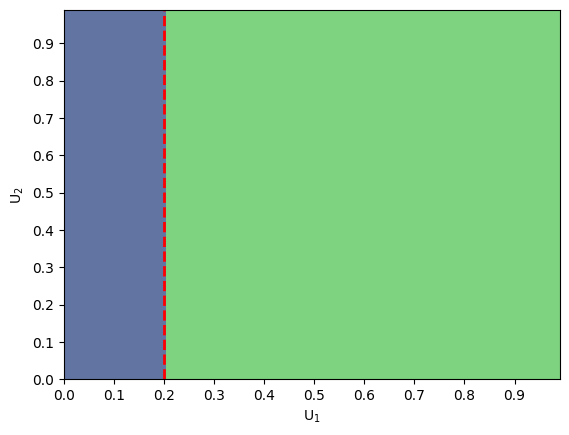

In [8]:
Pre1 = matrix(pre1).A
from collections import Counter
Pre_final1 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen1 = Pre1[:,i].reshape(1,-1)[0]
    fen_final1 = Counter(fen1).most_common()[0][0]
    Pre_final1.append(fen_final1)
Pre_final1 = np.array(Pre_final1).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final1,cmap = plt.cm.viridis,alpha = 0.8,levels=1)

#plt.contourf(plon,plat,ssh,np.arange(-1,1.001,0.001))
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
y1 = np.linspace(0, 1, 50)
x = 0.2+ y1-y1
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')


plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('inter1.eps', format='eps', dpi=300)
#plt.savefig("img13.png")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


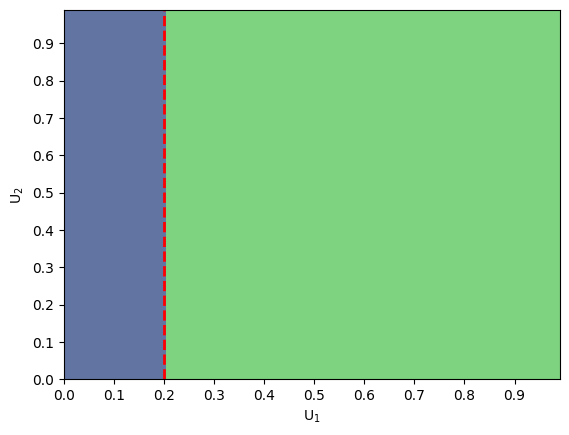

In [9]:
Pre2 = matrix(pre2).A
from collections import Counter
Pre_final2 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen2 = Pre2[:,i].reshape(1,-1)[0]
    fen_final2 = Counter(fen2).most_common()[0][0]
    Pre_final2.append(fen_final2)
Pre_final2 = np.array(Pre_final2).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.viridis,alpha = 0.8,levels=1)
#plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.Pastel2,alpha = 0.8)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
y1 = np.linspace(0, 1, 50)
x = 0.2+ y1-y1
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')

plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('inter2.eps', format='eps', dpi=300)
plt.show()
#beta1通过投票的最终预测

##### n = 800

In [60]:
np.random.seed(110)
Deviation_0 = []
Deviation_1 = []
Deviation_2 = []
Deviation1_1 = []
Deviation1_2 = []
Deviation2_1 = []
Deviation2_2 = []
beta0_all = []
beta1_all = []
beta2_all = []
alpha1_1all =[]
alpha1_2all =[]
alpha2_1all = []
alpha2_2all = []
ACC1 = []
ACC2 = []
ACC_final = []
ACC_pre = []
K1 = []
K2 =  []
RI1 = []
RI2 = []
ACCp2 = []
ACCp1 = []
ACCp_final = []
beta0_allor = []
beta1_allor = []
beta2_allor = []
alpha1_1allor = []
alpha1_2allor = []
alpha2_1allor = []
alpha2_2allor = []
lst1 = []
lst2 = []
Pre1 = []
Pre2 = []
n = 800
import time
start = time.perf_counter()
for i in range(200):
    print(i)
    #生成要训练的数据
    beta_0 = 1
    beta_1 = 1
    beta_2 = 1
    X1 = np.random.uniform(low=0.0, high=1, size = n)
    Z1 = np.random.uniform(low=0.0, high=1, size = n)
    random_u = X1 * Z1


    #定义变系数beta1(x)
    def alpha11(x):
        if (x >= 0) & (x < 0.2):
            return -1
        elif (x >= 0.2) & (x <=  1):
            return 1
        else:
            return None

    #生成变系数beta1(x)数据
    alpha1 = []
    for i in random_u:
        alpha1_1 = alpha11(i)
        alpha1.append(alpha1_1)

    #定义系数alpha2
    def alpha22(x):
        if (x >= 0) & (x < 0.2):
            return -1.5
        elif (x >= 0.2) & (x <= 1):
            return 0.5
        else:
            return None

    alpha2 = []
    for i in random_u:
        alpha2_2 = alpha22(i)
        alpha2.append(alpha2_2)

    # 随机生成X1 X2
    X0 = np.ones(n)
    #X1 = np.random.normal(loc=0,scale=1,size=n)
    X2 = np.random.normal(loc=0,scale=1,size=n)
    # 随机生成Z1 Z2

    #Z1 = np.random.binomial(n = 1,p = 0.5,size = n)
    Z2 = np.random.normal(loc=0,scale=1,size=n)
    # 随机生成服从正态分布的噪声
    epli =np.random.normal(loc=0,scale=0.5,size=n)#从正态（高斯）分布中抽取随机样本。
    #获取Y
    def func(X0,X1,X2,Z1,Z2):
        Y = A * X0 + B* X1 + C * X2 + D * Z1 + E* Z2 + eplison
        return Y
    Y1 = []
    for i in range(n):#生成数据的长度
        A = beta_0
        B = beta_1
        C  = beta_2
        D = alpha1[i]
        E = alpha2[i]
        eplison = epli[i]
        X0_0 = X0[i]
        X1_1 = X1[i]
        X2_1 = X2[i]

        Z1_1 = Z1[i]
        Z2_1 = Z2[i]
        Y1_1 = func(X0_0,X1_1,X2_1,Z1_1,Z2_1)
        Y1.append(Y1_1)

    #生成一列索引
    index = []
    for i in range(n):
        index_1 = i
        index.append(int(index_1))

    data_arry = []
    data_arry.append(index)
    data_arry.append(Y1)
    data_arry.append(X0)
    data_arry.append(X1)
    data_arry.append(X2)
    data_arry.append(Z1)
    data_arry.append(Z2)
    data_arry.append(random_u)
    data_arry.append(alpha1)
    data_arry.append(alpha2)
    np_data = np.array(data_arry)
    np_data = np_data.T
    np_data = np.array(np_data)
    save = pd.DataFrame(np_data,columns = ['index','Y1','X0','X1','X2', 'Z1', 'Z2','U','alpha1','alpha2']) 
    save.to_csv('ZGDP 1.1 first.csv',index=False,header=True)
    #随机生成要预测的数据
    X1 = np.random.uniform(low=0.0, high=1, size = n1)
    Z1 = np.random.uniform(low=0.0, high=1.00, size = n1)
    randompre_u = X1 * Z1
    #randompre_u = np.random.uniform(low=0.0, high=1.0, size = n1)
    #生成变系数beta1(x)数据
    alpha1p = []
    for i in randompre_u:
        alpha1_1 = alpha11(i)
        alpha1p.append(alpha1_1)
    alpha2p = []
    for i in randompre_u:
        alpha2_2 = alpha22(i)
        alpha2p.append(alpha2_2)

    # 随机生成X1 X2
    X0 = np.ones(n1)
    #X1 = randompre_u
    #X1 = np.random.normal(loc=0,scale=1,size=n)
    X2 = np.random.normal(loc=0,scale=1,size=n1)
    # 随机生成Z1 Z2

    #Z1 = np.random.binomial(n = 1,p = 0.5,size = n1)
    Z2 = np.random.normal(loc=0,scale=1,size=n1)
    # 随机生成服从正态分布的噪声
    eplip =np.random.normal(loc=0,scale=0.5,size=n1)#从正态（高斯）分布中抽取随机样本。

    Yp = []
    for i in range(n1):#生成数据的长度
        A = beta_0
        B = beta_1
        C  = beta_2
        D = alpha1p[i]
        E = alpha2p[i]
        eplison = eplip[i]
        X0_0 = X0[i]
        X1_1 = X1[i]
        X2_1 = X2[i]

        Z1_1 = Z1[i]
        Z2_1 = Z2[i]
        Y1_1 = func(X0_0,X1_1,X2_1,Z1_1,Z2_1)
        Yp.append(Y1_1)
    #生成一列索引
    indexp = []
    for i in range(n1):
        index_1 = i
        indexp.append(int(index_1))
    data_arrypre = []
    data_arrypre.append(indexp)
    data_arrypre.append(Yp)
    data_arrypre.append(X0)
    data_arrypre.append(X1)
    data_arrypre.append(X2)
    data_arrypre.append(Z1)
    data_arrypre.append(Z2)
    data_arrypre.append(randompre_u)
    data_arrypre.append(alpha1p)
    data_arrypre.append(alpha2p)
    np_datapre = np.array(data_arrypre)
    np_datapre = np_datapre.T
    np_datapre = np.array(np_datapre)
    savepre = pd.DataFrame(np_datapre,columns = ['index','Y1','X0','X1','X2', 'Z1', 'Z2','U','alpha1','alpha2']) 
    savepre.to_csv('ZGDP 1.1 first pre.csv',index=False,header=True) 
    filenamepre = 'ZGDP 1.1 first pre.csv'
    datapre = read_csv(filenamepre)
    #生成判罚阵
    
    # 导入随机生成的数据
    filename = 'ZGDP 1.1 first.csv'
    data = read_csv(filename)

    with open('ZGDP 1.1 first.csv','r')as file:#'r'为读取文本
        reader = csv.DictReader(file)
        datas = [row for row in reader]

    def distance(d1, d2):
        """2范数，即欧几里得距离
           1范数，曼哈顿距离"""
        res = 0
        for key in("U"):
            #res+=abs((float(d1[key])-float(d2[key])))#一范数
            res+=(float(d1[key])-float(d2[key]))**2  #二范数
        return res
    #定义距离函数
    #影响knn的一般为距离的定义和k的取值，所以我把距离函数单独定义一下，这样方便更换

    #KNN计算离点最近的K-1个点，这是因为此时我在计算距离时并没有把自身排除，在排序时总有它自身距离自身为0的一个点
    K = 5  #以2-NN为例
    def KNN(data):
        #1.距离
        res = [
            {"index": train['index'],"distance": distance(data,train)}
            #diatance(data,train)
            for train in datas
        ]
        #2升序排列
        res = sorted(res , key = lambda item:item["distance"])
         #3.取前K个
        res2 = res[0:K]
        r2 = []
        for r in res2:
            r_1 = r["index"]
            r2.append(r_1)
        #print(res2)
        #print(r2)
        return r2
    k = 4#与前面的K-1相等
    G = np.zeros(shape=(n*k,n))#nk*n维矩阵
    #G  生成nk*n的零矩阵

    for i in range(0,n):
        for m in range(0,k):
            G[m+k*i][i] =  1
            ##k行一个元素为1 
    #G

    for j in range(0,n):
        list1 = KNN(datas[j])
        list2 = list1[1:]#取最近的K-1 = k个值
        for i in range(0,k):
            r_12 = int(float(list2[i]))
            G[i+j*k][r_12] = -1
            #G[i+j][#knn的那几个元素] = -1 
    #生成所需要的G矩阵
    
    #给初值
    lam = 0.00001
    m = 2
    I_p = np.diag(np.ones(m))
    A = np.kron(G,I_p)
    X = (np.array([data['X0'].values,data['X1'].values,data['X2'].values])).T
    Z = np.array([data['Z1'].values,data['Z2'].values]).T
    Z_1 = np.diag(data['Z1'].values)
    Z_2 = np.diag(data['Z2'].values)
    Y_1 = data['Y1'].values
    I_n = np.diag(np.ones(n))
    Q_1 = np.dot(X,np.linalg.pinv(np.dot(X.T,X)))
    Q_X = I_n - np.dot(Q_1,X.T)

    Z00 = []
    for i in range(n):
        Z00 = sl.block_diag(Z00,Z[i])
        i = i+1
    Z00 = np.delete(Z00, 0, 0) #块对角化.Z = (Z_1^T,...,Z_n^T)
    
    alpha_intial = np.dot(np.linalg.pinv(np.dot(np.dot(Z00.T,Q_X),Z00)+lam* np.dot(A.T,A)),np.dot(np.dot(Z00.T,Q_X),Y_1))
    beta_intial = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),Y_1 - np.dot(Z00,alpha_intial))
    alpha11 = []
    alpha22 = []
    for i in range(n):
        alpha_11 = alpha_intial[2*i]
        alpha_22 = alpha_intial[2*i+1]
        alpha11.append(alpha_11)
        alpha22.append(alpha_22)
    alpha11 = np.array(alpha11)
    alpha22 = np.array(alpha22)
    
    alpha1_before  = data['alpha1'].values
    alpha2_before  = data['alpha2'].values
    beta = beta_intial
    lam =1
    rho = 1
    gamma  = 2
    alpha1 = alpha11
    alpha2 = alpha22

    alpha1_old = alpha1
    alpha2_old = alpha2
    delta1 = np.dot(G,alpha1)
    delta2 = np.dot(G,alpha2)
    mu1 = np.ones(4*n) - 1
    mu2 = np.ones(4*n) - 1
    epsilon = 1e-4
    k=0
    F1=[]
    F2 = []
    F3 = []
    #每步计算结果
    while k < 50:#迭代
        alpha1 = np.dot(np.linalg.pinv(np.dot(np.dot(Z_1.T,Q_X),Z_1) +rho* np.dot(G.T,G)),
                        (np.dot(np.dot(Z_1.T,Q_X),(Y_1 - np.dot(Z_2,alpha2))) + rho * np.dot(G.T,delta1 - 1/rho*mu1)))
        alpha2 = np.dot(np.linalg.pinv(np.dot(np.dot(Z_2.T,Q_X),Z_2) + rho* np.dot(G.T,G)),
                        (np.dot(np.dot(Z_2.T,Q_X),(Y_1 - np.dot(Z_1,alpha1))) + rho * np.dot(G.T,delta2 - 1/rho*mu2)))
        beta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),Y_1 - np.dot(Z_1,alpha1)-np.dot(Z_2,alpha2)) 

        ras1 = []
        bb1 = np.dot(G,alpha1)+1/rho*mu1
        for i in range(4*n):
            b  = bb1[i]
            res1 = MCP(b,lam/rho,gamma,rho,lam)
            ras1.append(res1)
        delta1 = np.asarray(ras1)
        ras2 = []
        bb2 = np.dot(G,alpha2)+1/rho*mu2
        for i in range(4*n):
            b  = bb2[i]
            res2 = MCP(b,lam/rho,gamma,rho,lam)
            ras2.append(res2)
        delta2 = np.asarray(ras2)
        mu1 = mu1 + rho*(np.dot(G,alpha1) - delta1)
        mu2 = mu2 + rho*(np.dot(G,alpha2) - delta2)
        k = k+1

        #停止迭代的条件 
        F1.append(beta)
        if np.linalg.norm(mu1)/(4*n) < epsilon and np.linalg.norm(mu2)/(4*n) < epsilon:
                break
        else:
            alpha1_old = alpha1 
            alpha2_old = alpha2
            #迭代过程 
    #预测组数K1，K2
    alpha1_sort = np.sort(alpha1)
    lst1.append(alpha1)
    lst2.append(alpha2)
    biandian1 = np.diff(alpha1_sort)
    location_1 = np.array(np.where(abs(biandian1) > 0.4))
    location_1 = np.insert(location_1, 0, 0)  # 在0号位置插入元素0
    location_1 = np.insert(location_1, len(location_1), n-2)  # 在数组末尾插入元素
    #location_11 = np.where(np.diff(location_1)> 0.05*800)
    K_1 = np.count_nonzero(np.diff(location_1)> 0.1*n)
    K1.append(K_1)
    alpha2_sort = np.sort(alpha2)
    biandian2 = np.diff(alpha2_sort)
    location_2 = np.array(np.where(abs(biandian2) > 0.4))
    location_2 = np.insert(location_2, 0, 0)  # 在0号位置插入元素0
    location_2 = np.insert(location_2, len(location_2), n-2)  # 在数组末尾插入元素
    K_2 = np.count_nonzero(np.diff(location_2)> 0.05*n)
    K2.append(K_2)
    #尝试计算RI
    filename = 'ZGDP 1.1 first.csv'
    data = read_csv(filename)    
    result_array = []
    index_1 = data['index'].values
    Y1 = data['Y1'].values
    Z1 = data['Z1'].values
    Z2 = data['Z2'].values
    X0 = data['X0'].values
    X1 = data['X1'].values
    X2 = data['X2'].values
    result_array.append(index_1)
    result_array.append(Y1)
    result_array.append(Z1)
    result_array.append(Z2)
    result_array.append(X0)
    result_array.append(X1)
    result_array.append(X2)
    result_array.append(random_u)
    result_array.append(alpha1_before)
    result_array.append(alpha2_before)
    alpha1_unsort = np.squeeze(np.array(alpha1))
    result_array.append(alpha1_unsort)
    alpha2_unsort = np.squeeze(np.array(alpha2))
    result_array.append(alpha2_unsort)
    result_data = np.array(result_array)
    result_data = result_data.T
    result = pd.DataFrame(result_data, columns = ['index','Y','Z1','Z2','X0','X1','X2','U','alpha1_origin','alpha2_origin','alpha1','alpha2'])   
    result.sort_values(by="alpha1" , inplace=True, ascending=True)
    result['new_label1diff']=abs(result['alpha1'].diff(-1).shift())#做alpha1差分,添加列
    result = result.fillna(0)#nan替换为0
    result.reset_index(drop=True, inplace=True)#行号变回来，为了便于根据差分赋值

    dfsuoyin11 = result.loc[result['new_label1diff'] > 0.5] #提取变点的位置
    biandianxu11 = dfsuoyin11.index.values
    biandianxu11 = np.insert(biandianxu11, 0, 0, axis=None)
    biandianxu11 = np.insert(biandianxu11, len(biandianxu11), n, axis=None)
    labels_pred11 = np.zeros(n,int)
    for i in range(len(biandianxu11)-1):
        labels_pred11[biandianxu11[i]:biandianxu11[i+1]] = i
    labels_pred11[biandianxu11[len(biandianxu11)-1]:n] = len(biandianxu11)#给出预测的分组结果
    result['labels1_true'] = result.alpha1_origin.apply(lambda x: 1 if x == -1  else 0)
    labels1_true = result['labels1_true'].values
    RI1_1 = rand_index_score(labels1_true, labels_pred11)
    RI1.append(RI1_1)
 
    result.sort_values(by="alpha2" , inplace=True, ascending=True)
    result['new_label2diff']=abs(result['alpha2'].diff(-1).shift())#做alpha2差分,添加列
    result = result.fillna(0)#nan替换为0
    result.reset_index(drop=True, inplace=True)#行号变回来，为了便于根据差分赋值
    dfsuoyin21 = result.loc[result['new_label2diff'] > 0.5] 
    biandianxu21 = dfsuoyin21.index.values
    biandianxu21 = np.insert(biandianxu21, 0, 0, axis=None)
    biandianxu21 = np.insert(biandianxu21, len(biandianxu21), n, axis=None)
    labels_pred21 = np.zeros(n,int)
    for i in range(len(biandianxu21)-1):
        labels_pred21[biandianxu21[i]:biandianxu21[i+1]] = i
    labels_pred21[biandianxu21[len(biandianxu21)-1]:n] = len(biandianxu21)#根据变点和其索引赋值分组标签
    result['labels2_true'] = result.alpha2_origin.apply(lambda x: 1 if x == 0.5  else 0)
    labels2_true = result['labels2_true'].values
    RI2_1 = rand_index_score(labels2_true, labels_pred21)
    RI2.append(RI2_1)
    
    #做分类
    U1 = np.ones(n)
    result.insert(4, 'U1',U1, allow_duplicates=False)
    label1= []
    for i in range(n):
        if result.alpha1[i]>=0:
            label1_1 = 1
        else:
            label1_1 = -1
        label1.append(label1_1)
    label1 = np.array(label1)
    clf1 = SVC(kernel='linear',C=10)  
    Z_ob = result[['U','U1']]
    clf1.fit(X=Z_ob,y=label1)
    accsvc1 = clf1.score(X=Z_ob,y=label1)#得分
    accp1 = clf1.predict(X=Z_ob) 
    acc1 = 1-np.count_nonzero((accp1 - label1))/len(accp1)
    ACC1.append(acc1)
    #做预测
    U11 = np.ones(n1)
    datapre.insert(4, 'U1',U11, allow_duplicates=False)
    pre1 = clf1.predict(datapre[['U','U1']])
    acc_pre1 = 1-np.count_nonzero((pre1 - datapre.alpha1))/len(pre1)
    ACCp1.append(acc_pre1)
    x_min,x_max = 0,1#取横坐标的取值范围
    y_min,y_max = 0,1#取纵坐标的取值范围
    xx,yy = np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))#生成网格点
    Z = clf1.predict(np.c_[xx.ravel(),yy.ravel()])#用我们的模型预测出来的网格点中的所有的值
    Pre1.append(Z)

    #2的准确率
    label2= []
    for i in range(n):
        if result.alpha2[i]>-0.5:
            label2_1 = 1
        else:
            label2_1 = -1
        label2.append(label2_1)
    label2 = np.array(label2)
    clf2 = SVC(kernel='linear',C=10)
    clf2.fit(X=Z_ob,y=label2)
    accsvc2 = clf2.score(X=Z_ob,y=label2)#得分
    accp2 = clf2.predict(X=Z_ob)
    Z2 = clf2.predict(np.c_[xx.ravel(),yy.ravel()])
    Pre2.append(Z2)
    
    label2_result = []
    for i in range(n):
        if result.alpha2_origin[i] == -1.5:
            label2_result1 = -1
        else:
            label2_result1 = 1
        label2_result.append(label2_result1)
    label2_result = np.array(label2_result)
    acc2 = 1-np.count_nonzero((accp2 - label2_result))/len(accp2)
    ACC2.append(acc2) 
    #做预测
    pre2_datapre = []
    for i in range(n1):
        if datapre.alpha2[i] == -1.5:
            pre2_datapre1 = -1
        else:
            pre2_datapre1 = 1
        pre2_datapre.append(pre2_datapre1)
    pre2_datapre = np.array(pre2_datapre)
    pre2 = clf2.predict(datapre[['U','U1']])
    acc_pre2 = 1-np.count_nonzero((pre2 - pre2_datapre))/len(pre2)
    ACCp2.append(acc_pre2)
    #计算准确率
    acc_origin = []
    acc_origin.append(accp1 - label1)
    acc_origin.append(accp2 - label2_result)
    acc_origin = np.array(acc_origin)
    #训练集的总正确率
    acc1_final = np.array(np.linalg.norm(x=acc_origin.T, ord=1, axis=1, keepdims=False))
    acc_final = np.sum(acc1_final==0)/len(acc1_final)
    ACC_final.append(acc_final)
    #测试集的准确率
    acc_pre = []
    acc_pre.append(pre1 - datapre.alpha1)
    acc_pre.append(pre2 - pre2_datapre)
    acc_pre = np.array(acc_pre)
    acc2_final = np.array(np.linalg.norm(x=acc_pre.T, ord=1, axis=1, keepdims=False))
    acc_prefinal = np.sum(acc2_final==0)/len(acc2_final)
    ACC_pre.append(acc_prefinal)
 
    
    z1 = np.array(result.Z1)
    z2 = np.array(result.Z2)
    #oracle下回归结果
    
    I11_or = []
    for i in result.alpha1_origin:
        I1_1or = I_11or(i)
        I11_or.append(I1_1or)
    I12_or = []
    for i in result.alpha1_origin:
        I1_2or = I_12or(i)
        I12_or.append(I1_2or)
        
    I21_or = []
    for i in result.alpha2_origin:
        I2_1or = I_21or(i)
        I21_or.append(I2_1or)
    I22_or = []
    for i in result.alpha2_origin:
        I2_2or = I_22or(i)
        I22_or.append(I2_2or)
        
    zI_111or = z1*I11_or
    zI_112or = z1*I12_or
    zI_221or = z2*I21_or
    zI_222or = z2*I22_or
    data_modelor = []
    Y1 = result['Y'].values
    X0 = result['X0'].values
    X1 = result['X1'].values
    X2 = result['X2'].values
    data_modelor.append(Y1)
    data_modelor.append(X0)
    data_modelor.append(X1)
    data_modelor.append(X2)
    data_modelor.append(zI_111or)
    data_modelor.append(zI_112or)
    data_modelor.append(zI_221or)
    data_modelor.append(zI_222or)
    data_modelor = np.array(data_modelor)
    data_modelor = data_modelor.T
    data_modelor = pd.DataFrame(data_modelor, columns = ['Y','X0','X1','X2','z1*I11','z1*I12','z2*I21','z2*I22']) 
    train_colsor = data_modelor.columns[1:]
    linear_or = sm.OLS(data_modelor['Y'],data_modelor[train_colsor])
    result_for = linear_or.fit()
    beta0_or = result_for.params.iloc[0]
    beta1_or = result_for.params.iloc[1]
    beta2_or = result_for.params.iloc[2]
    alpha1_1or = result_for.params.iloc[3]
    alpha1_2or = result_for.params.iloc[4]
    alpha2_1or = result_for.params.iloc[6]
    alpha2_2or = result_for.params.iloc[5]

    beta0_alor = beta0_or
    beta1_alor = beta1_or
    beta2_alor = beta2_or
    alpha1_1alor = alpha1_1or
    alpha1_2alor = alpha1_2or
    alpha2_1alor = alpha2_1or
    alpha2_2alor = alpha2_2or
    
    beta0_allor.append(beta0_alor)
    beta1_allor.append(beta1_alor)
    beta2_allor.append(beta2_alor)
    alpha1_1allor.append(alpha1_1alor)
    alpha1_2allor.append(alpha1_2alor)
    alpha2_1allor.append(alpha2_1alor)
    alpha2_2allor.append(alpha2_2alor) 

    #knn fused penalty function 下的分组结果做判罚
    I11 = []
        #for i in random_u:
    for i in label1:
    #for i in alpha1_result:
        I1_1 = I_11(i)
        I11.append(I1_1)
    I12 = []
    #for i in alpha1_result:
    for i in label1:
        #for i in random_u:
        I1_2 = I_12(i)
        I12.append(I1_2)

    I21 = []
    for i in label2:
        #for i in random_u:
    #for i in alpha2_result:
        I2_1 = I_21(i)
        I21.append(I2_1)
    I22 = []
        #for i in random_u:
        #for i in alpha2_result:
    for i in label2:
    #for i in alpha2_result:
        I2_2 = I_22(i)
        I22.append(I2_2)
    zI_111 = z1*I11
    zI_112 = z1*I12
    zI_221 = z2*I21
    zI_222 = z2*I22
    data_model = []
    Y1 = result['Y'].values
    X0 = result['X0'].values
    X1 = result['X1'].values
    X2 = result['X2'].values
    data_model.append(Y1)
    data_model.append(X0)
    data_model.append(X1)
    data_model.append(X2)
    data_model.append(zI_111)
    data_model.append(zI_112)
    data_model.append(zI_221)
    data_model.append(zI_222)
    data_model = np.array(data_model)
    data_model = data_model.T
    data_model = pd.DataFrame(data_model, columns = ['Y','X0','X1','X2','z1*I11','z1*I12','z2*I21','z2*I22']) 
    train_cols = data_model.columns[1:]
    linear = sm.OLS(data_model['Y'],data_model[train_cols])
    result_f = linear.fit()
    result_f.summary()
    beta0_old = 1
    beta1_old = 1
    beta2_old = 1
    alpha1_1_old = -1
    alpha1_2_old = 1
    alpha2_1_old = -1.5
    alpha2_2_old = 0.5


    beta0 = result_f.params.iloc[0]
    beta1 = result_f.params.iloc[1]
    beta2 = result_f.params.iloc[2]
    alpha1_1 = result_f.params.iloc[3]
    alpha1_2 = result_f.params.iloc[4]
    alpha2_1 = result_f.params.iloc[5]
    alpha2_2 = result_f.params.iloc[6]

    deviation_0 = beta0-beta0_old
    deviation_1 = beta1-beta1_old
    deviation_2 = beta2-beta2_old

    deviation1_1 = (alpha1_1-alpha1_1_old)
    deviation1_2 = (alpha1_2-alpha1_2_old)
    deviation2_1 = (alpha2_1-alpha2_1_old)
    deviation2_2 = (alpha2_2-alpha2_2_old)
    
    beta0_al = beta0
    beta1_al = beta1
    beta2_al = beta2
    alpha1_1al = alpha1_1
    alpha1_2al = alpha1_2
    alpha2_1al = alpha2_1
    alpha2_2al = alpha2_2
    Deviation_0.append(deviation_0)
    Deviation_1.append(deviation_1)
    Deviation_2.append(deviation_2)
    Deviation1_1.append(deviation1_1)
    Deviation1_2.append(deviation1_2)
    Deviation2_1.append(deviation2_1)
    Deviation2_2.append(deviation2_2)
    beta0_all.append(beta0_al)
    beta1_all.append(beta1_al)
    beta2_all.append(beta2_al)
    alpha1_1all.append(alpha1_1al)
    alpha1_2all.append(alpha1_2al)
    alpha2_1all.append(alpha2_1al)
    alpha2_2all.append(alpha2_2al) 

end = time.perf_counter()
execution_time_1 = (end - start)/200
print('execution time:',execution_time_1) 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
execution time: 42.25082076418214


In [61]:
result_need = []
result_need.append(K1)
result_need.append(K2)
result_need.append(RI1)
result_need.append(RI2)

result_need.append(beta0_all)
result_need.append(beta1_all)
result_need.append(beta2_all)
result_need.append(alpha1_1all)
result_need.append(alpha1_2all)
result_need.append(alpha2_1all)
result_need.append(alpha2_2all)
result_need.append(beta0_allor)
result_need.append(beta1_allor)
result_need.append(beta2_allor)
result_need.append(alpha1_1allor)
result_need.append(alpha1_2allor)
result_need.append(alpha2_1allor)
result_need.append(alpha2_2allor)
result_need.append(ACC1)
result_need.append(ACCp1)
result_need.append(ACC2)
result_need.append(ACCp2)
result_need.append(ACC_final)
result_need.append(ACC_pre)
result_need = np.array(result_need)
result_need = result_need.T
result_need = np.array(result_need)
save_need1 = pd.DataFrame(result_need,columns = ['K1','K2','RI1','RI2','beta_0','beta_1','beta_2','alpha1_1','alpha1_2','alpha2_1','alpha2_2','beta_0^{or}','beta_1^{or}','beta_2^{or}','alpha1_1^{or}','alpha1_2^{or}','alpha2_1^{or}','alpha2_2^{or}','ACC1','ACCp1','ACC2','ACCp2','ACC_final','ACC_pre']) 
save_need1.to_csv('XGDP inter first with n = 800.csv',index=False,header=True) 
data1 = save_need1
data1

,K1,K2,RI1,RI2,beta_0,beta_1,beta_2,alpha1_1,alpha1_2,alpha2_1,...,alpha1_1^{or},alpha1_2^{or},alpha2_1^{or},alpha2_2^{or},ACC1,ACCp1,ACC2,ACCp2,ACC_final,ACC_pre
0,2.0,2.0,0.972262,0.961574,1.018460,0.983915,1.020522,-1.078744,0.963363,-1.505686,...,-1.079976,0.943600,0.501610,-1.502114,0.99000,1.000,0.99750,0.990,0.98750,0.990
1,2.0,2.0,0.977785,0.970407,1.046270,0.966174,0.995154,-1.104580,0.991849,-1.523354,...,-1.062423,1.000842,0.544448,-1.516434,0.99625,1.000,0.99750,0.990,0.99375,0.990
2,2.0,2.0,0.988889,0.981527,1.044072,0.860812,1.015937,-0.893950,1.085035,-1.503673,...,-0.908432,1.076870,0.496707,-1.501001,0.99000,0.995,0.99375,0.995,0.99000,0.995
3,2.0,2.0,0.836924,0.974002,0.881175,1.113509,0.984554,-0.859665,0.960913,-1.494918,...,-0.962824,0.941647,0.450356,-1.502311,0.86125,0.955,0.99375,1.000,0.85875,0.955
4,2.0,2.0,0.976696,0.992171,1.144739,0.837963,0.990717,-1.198561,1.005673,-1.450029,...,-1.207463,1.001268,0.448308,-1.449220,0.99125,0.985,0.99250,0.985,0.99125,0.985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.0,2.0,0.499722,0.979872,0.884527,1.070932,1.029352,-0.765993,1.096820,-1.506812,...,-0.836225,1.076795,0.480418,-1.509899,0.98375,0.985,0.98875,0.985,0.97250,0.985
196,2.0,2.0,0.980009,0.989831,0.900153,1.166423,1.004599,-0.855178,0.973293,-1.565288,...,-0.849555,0.972440,0.474947,-1.563841,0.99250,0.990,1.00000,1.000,0.99250,0.990
197,2.0,2.0,0.913921,0.957034,1.040945,0.914516,1.010337,-0.991108,1.009155,-1.484073,...,-1.024682,0.972693,0.496814,-1.478125,0.97750,0.995,0.98625,0.980,0.96750,0.980
198,2.0,2.0,0.971837,0.960078,0.830890,1.137145,1.007733,-0.758968,1.154516,-1.492074,...,-0.726622,1.134397,0.552872,-1.486727,0.98750,1.000,0.99375,1.000,0.98125,1.000


In [62]:
#Table1的数据的输出
print([data1['K1'].median(axis=0),(data1['K1'].mean(axis=0) - 2),
 np.std((data1.K1), ddof=1),(data1['RI1'].mean(axis=0)),np.sum(data1.K1 == 2)/len(data1.K1)])
print([data1['K2'].median(axis=0),(data1['K2'].mean(axis=0) - 2),
 np.std((data1.K2), ddof=1),(data1['RI2'].mean(axis=0)),np.sum(data1.K2 == 2)/len(data1.K2)])
print([data1.ACC1.mean(),data1.ACC2.mean(),data1.ACC_final.mean(),data1.ACCp1.mean(),data1.ACCp2.mean(),data1.ACC_pre.mean()])

[np.float64(2.0), np.float64(-0.020000000000000018), np.float64(0.1403513179927839), np.float64(0.9331287859824781), np.float64(0.98)]
[np.float64(2.0), np.float64(0.0), np.float64(0.0), np.float64(0.9788122340425532), np.float64(1.0)]
[np.float64(0.9844124999999999), np.float64(0.9936437499999999), np.float64(0.9812812500000001), np.float64(0.9910249999999999), np.float64(0.992375), np.float64(0.989025)]


In [63]:
#Table2 的输出
#beta_0的输出
print([data1.beta_0.mean(axis=0) - 1,np.std((data1.beta_0),ddof=1),
       data1.beta_0.var(axis=0)+ (data1.beta_0.mean(axis=0) - 1)**2])
#beta_1的输出
print([data1.beta_1.mean(axis=0) - 1,np.std((data1.beta_1),ddof=1),
       data1.beta_1.var(axis=0)+ (data1.beta_1.mean(axis=0) - 1)**2])
#print([data1.beta_0.mean(axis=0) - 1,data1.beta_0.var(axis=0)])
#beta_2的输出
print([data1.beta_2.mean(axis=0) - 1,np.std((data1.beta_2),ddof=1),
       data1.beta_2.var(axis=0)+ (data1.beta_2.mean(axis=0) - 1)**2])

#alpha1_1的输出
print([data1.alpha1_1.mean(axis=0) + 1,np.std((data1.alpha1_1),ddof=1),
       data1.alpha1_1.var(axis=0)+ (data1.alpha1_1.mean(axis=0) + 1)**2])

#alpha12的输出
print([data1.alpha1_2.mean(axis=0) - 1,np.std((data1.alpha1_2),ddof=1),
       data1.alpha1_2.var(axis=0)+ (data1.alpha1_2.mean(axis=0) - 1)**2])

#alpha21的输出
print([data1.alpha2_1.mean(axis=0) + 1.5,np.std((data1.alpha2_1),ddof=1),
       data1.alpha2_1.var(axis=0)+ (data1.alpha2_1.mean(axis=0) + 1.5)**2])
#alpha22的输出
print([data1.alpha2_2.mean(axis=0) -0.5,np.std((data1.alpha2_2),ddof=1),
       data1.alpha2_2.var(axis=0)+ (data1.alpha2_2.mean(axis=0) -0.5)**2])

[np.float64(-0.02046978770581409), np.float64(0.06298812778735544), np.float64(0.0043865164508773155)]
[np.float64(0.019440593952723795), np.float64(0.08705269972610992), np.float64(0.00795610922283894)]
[np.float64(0.0010363675858606758), np.float64(0.01784736472789989), np.float64(0.0003196024855037078)]
[np.float64(0.02581699402838633), np.float64(0.1077403645452604), np.float64(0.01227450333300734)]
[np.float64(0.006718259856911102), np.float64(0.05996917982113195), np.float64(0.003641437543924243)]
[np.float64(-0.0034429303364407193), np.float64(0.02585444449018551), np.float64(0.0006803060691976678)]
[np.float64(-0.0011704931666693397), np.float64(0.024051596506938906), np.float64(0.0005798493487858153)]


In [64]:
pre1 = pd.DataFrame(Pre1)
pre1.to_csv('XGDP inter first with n = 800 pre1.csv',index=False,header=True)

pre2 = pd.DataFrame(Pre2)
pre2.to_csv('XGDP inter first with n = 800 pre2.csv',index=False,header=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


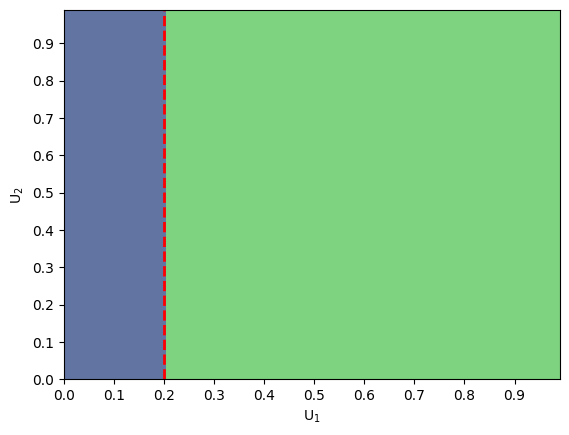

In [65]:
Pre1 = matrix(pre1).A
from collections import Counter
Pre_final1 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen1 = Pre1[:,i].reshape(1,-1)[0]
    fen_final1 = Counter(fen1).most_common()[0][0]
    Pre_final1.append(fen_final1)
Pre_final1 = np.array(Pre_final1).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final1,cmap = plt.cm.viridis,alpha = 0.8,levels=1)

#plt.contourf(plon,plat,ssh,np.arange(-1,1.001,0.001))
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
y1 = np.linspace(0, 1, 50)
x = 0.2+ y1-y1
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')


plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('inter11.eps', format='eps', dpi=300)
#plt.savefig("img13.png")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


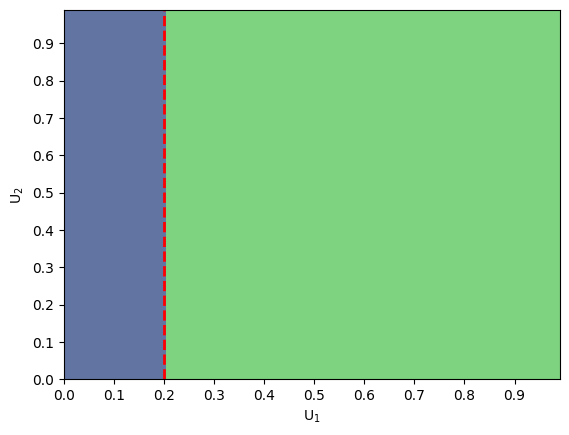

In [66]:
Pre2 = matrix(pre2).A
from collections import Counter
Pre_final2 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen2 = Pre2[:,i].reshape(1,-1)[0]
    fen_final2 = Counter(fen2).most_common()[0][0]
    Pre_final2.append(fen_final2)
Pre_final2 = np.array(Pre_final2).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.viridis,alpha = 0.8,levels=1)
#plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.Pastel2,alpha = 0.8)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
y1 = np.linspace(0, 1, 50)
x = 0.2+ y1-y1
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')

plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('inter12.eps', format='eps', dpi=300)
plt.show()
#beta1通过投票的最终预测